# Majorant\_v2 — open cascades on the conservative engine

This notebook runs the two open configurations, coagulation and fragmentation, on
`BF_v_no_resampling_v2.py`. One simulated particle stands for exactly one physical
particle for the whole run, so the total number and the total mass are conserved to
machine precision and the reported `mass_drift` is identically zero; anything else is
a bug rather than a fluctuation. That is what *conservative* means in the names of
the files this notebook writes.

An open system has a source and an absorbing boundary, so a genuine steady state
exists and the spectrum to measure is the **instantaneous** one rather than a
superposition over time. $\Delta t$ never enters the estimator, which is why the
closed notebook has to agonise over the snapshot cadence and this one does not — and
which is also why every snapshot taken after the cascade reached the sink is an
independent draw from the same distribution, so they are averaged rather than thrown
away. That average costs nothing and is worth a factor $\sqrt{K}$ in noise. The theory
under test is

$$\alpha = -\frac{3+\lambda}{2}, \qquad b = \frac{2}{1-\lambda},$$

with $\lambda$ the homogeneity degree of the kernel, $\alpha$ the slope of $dN/dm$
across the inertial range and $b$ the growth exponent read from the isochrones.
Coagulation injects monomers at $m_{\rm inj}$ and absorbs products above
$m_{\rm sink}$; fragmentation injects large bodies at $m_{\rm inj}$ and absorbs
fragments below $m_{\rm sink}$. The two share $\alpha$ and $b$ exactly, and only the
direction of the drift changes.

Spectra are drawn compensated, as $m^2\,dN/dm$ — the mass per logarithmic mass
interval, whose slope is $\alpha+2$. Every fit is performed on the raw $dN/dm$ and
the compensation is applied at draw time only, so the reported index is never the
compensated one.

Each successful run is written into `runs/` by `add_last_run`, keeping the spectra,
the isochrone histogram and all the parameters but discarding the per-particle
arrays. The analysis notebooks in that folder rebuild every figure from those files,
so a plot can be changed without paying for the simulation again.


## How the index is measured

A measured spectrum is a power law only *between* the two characteristic masses of
the problem. Outside that band it bends — at the injection scale because of the
source, at the sink because of truncation and vanishing statistics — and a single fit
across the whole array averages the plateau together with both bends, returning a
number that describes neither. What is measured here instead is the plateau in the
local slope,

$$\Gamma(m)=\frac{d\log F}{d\log m},$$

computed by least squares on a sliding window. `BF.find_inertial_range` returns the
longest contiguous stretch over which $\Gamma$ stays flat within a tolerance,
together with that stretch's mean, its scatter and its width in decades. The mean is
the measured $\alpha$: it is what enters the summary table and it is the line drawn
over the spectrum. When it comes back as `nan` the run simply has no inertial range
yet, which is the correct answer rather than a failure. What it is computed on is
`steady_spectrum`, the mean of the snapshots taken after the sink gate opened, not a
single snapshot.

Running alongside it is the a-priori guard band, half a decade stripped from each end
of the interval between $m_{\rm inj}$ and $m_{\rm sink}$, chosen before anyone looks
at the data. The two must agree; where they do not, the cascade has not developed
over the range that was assumed. The width in decades is printed next to every index
because a plateau narrower than roughly one decade is not a power law however tight
its error bar looks, and because the plateau finder can only test whether the curve
you computed has a scaling region — not whether that curve is the right quantity to
have computed.


In [16]:
import os, importlib, inspect, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import BF_v_no_resampling_v2 as BF          # <-- v2 baseline engine, w == 1
importlib.reload(BF)

plt.rcParams.update({"figure.dpi":110, "font.size":9, "axes.grid":True,
                     "grid.alpha":0.25, "figure.figsize":(9,3.2)})

KERNEL = BF.kernel_geometric         # lambda = 2/3 (geometric cross section)
LAM    = BF.KERNEL_LAMBDA[KERNEL.__name__]
EDGES  = 10.0 ** np.arange(-4, 12, 0.1)   # top edge 10^7.9; see check_grid below


assert "stop_sink_events" in inspect.signature(BF.simulate).parameters, \
    "the engine on the path is not BF_v_no_resampling_v2.py"

print("engine =", BF.__name__)
print("kernel =", KERNEL.__name__, " lambda =", LAM)
PR = BF.predict("open", LAM)
print("  open   beta = %.4g   b = %.4g   alpha = %.4g" % (PR["beta"], PR["b"], PR["alpha"]))
print("  grid   %.3g .. %.3g  (%d bins of %.2f dex)"
      % (EDGES[0], EDGES[-1], EDGES.size-1, np.log10(EDGES[1]/EDGES[0])))

# Age bins must be chosen from b, not copied from the lambda = 0 notebook.  One age
# bin of width D_tau dex covers b * D_tau dex of MASS, so at b = 6 the old 0.15 dex
# step jumps 0.9 dex of mass per bin and the growth-law mask catches two bins.
# Fix the MASS resolution instead and let the age step follow.
AGE_STEP = 0.30 / PR["b"]          # 0.15 at b=2 (identical to the constant-kernel run)
print("  ages   %.3f dex per bin  ->  %.2f dex of mass per bin" % (AGE_STEP, 0.30))

RESULTS = {}   # collected for the summary table at the end


engine = BF_v_no_resampling_v2
kernel = kernel_geometric  lambda = 0.6666666666666666
  open   beta = 0.8333   b = 6   alpha = -1.833
  grid   0.0001 .. 7.94e+11  (159 bins of 0.10 dex)
  ages   0.050 dex per bin  ->  0.30 dex of mass per bin


In [17]:
# ----------------------------------------------------------------------
#  The measurement layer
# ----------------------------------------------------------------------
#  Everything that turns arrays into a number now lives in BF_analysis.py, next to
#  this notebook: the estimator and its error bars, the plateau finders, the
#  isochrone machinery and the saver.  Keeping it there rather than in a cell means
#  the run notebooks and the six analysis notebooks cannot drift apart, and that a
#  change to the estimator is one edit rather than nine.
#
#  The names are aliased below so the figure cells further down read exactly as
#  before.

import BF_analysis as AN

anchor_amplitude = AN.anchor_amplitude
pick_isochrones  = AN.pick_isochrones
draw_isochrones  = AN.draw_isochrones
compensated_ylim = AN.compensated_ylim
add_last_run     = AN.add_last_run


def steady_spectrum(run, frac=0.5):
    """
    (F, K): the averaged post-gate spectrum and how many snapshots went into it.

    AN.steady_spectrum returns the full dict -- F, the empirical and Poisson error
    bars, the raw counts and K_eff.  This shim keeps the two-value call used below;
    call AN.steady_spectrum directly when the error bars are wanted.
    """
    s = AN.steady_spectrum(run, frac=frac)
    return s["F"], s["K"]


def check_grid(*masses):
    """Refuse to start if a characteristic mass falls outside EDGES."""
    return AN.check_grid(EDGES, *masses)


---
## Open system with coagulation

Monomers are injected at $m_{\rm inj}$ at a constant rate and products crossing
$m_{\rm sink}$ are removed. The injection rate follows from the balance of particle
number in the steady state, where the accepted event rate must equal the injection
rate:

$$q = \frac{\langle K\rangle\,N_{\rm ss}^{2}}{2V}.$$

Writing $q=N^2/2$, as the original four-case notebook did, is that same expression at
$\langle K\rangle = 1$ — true for the constant kernel and for nothing else. Because
the population is dominated by the injection scale whenever $\alpha<-1$, most pairs
are $(m_{\rm inj},m_{\rm inj})$ and $\langle K\rangle$ is of order
$K(m_{\rm inj},m_{\rm inj})$, with heavier partners raising it by roughly a factor
two. `live` therefore settles somewhat below the nominal target, and that is fine;
what matters is that it settles at all and that $M_{\rm out}/M_{\rm in}$ heads
towards one.

Nothing in an open run may be gated on an absolute time. The clock advances by
$\Delta t = 2V/(wR)$ with $R\propto N^2$, so after $E$ trials

$$t \simeq \frac{2E}{N^{2}},$$

and raising $N$ at a fixed event budget makes the run *shorter* in physical time
rather than longer. A gate expressed as a time and tuned at one $N$ is never crossed
at ten times that $N$. Both gates used below are therefore counted in sink
absorptions: the isochrones begin accumulating once `iso_start_sink` particles have
crossed the entire inertial range, and the run ends after `stop_sink_events` of them.
Each is a statement about the physics and needs no retuning when $N$, the mass range
or the kernel changes. A ceiling on `max_events` is kept alongside them, not as the
criterion but as the guarantee that a mistuned $q$ cannot cost an afternoon;
`stop_reason` afterwards says which of the two actually bit.

The isochrone age bins are derived from $b$ rather than copied from a run at another
kernel. One age bin of width $\Delta_\tau$ dex spans $b\,\Delta_\tau$ dex of mass, so
the mass resolution is fixed at $0.3$ dex and the age step follows as
$\Delta_\tau = 0.3/b$.


In [10]:
# OPEN system: the steady state is the LAST snapshot, dt never enters the estimator,
# so snapshotting by events is perfectly fine here.
#
# The isochrone gate is PHYSICAL, not temporal: bin ages only after the sink has swallowed
# N_OUT particles.  In v2 that gate is armed by default (10) for BOTH processes; it is passed
# explicitly below only to keep the number visible next to the budget it implies.

N_SS   = 1e6
M_INJ  = 1.0
M_SINK = 1e6
N_OUT  = 10                                               # sink absorptions before binning ages
N_STOP = 100                                              # sink absorptions before STOPPING (see below)
MAX_EV = int(3 * (N_SS*np.sqrt(M_SINK) + N_STOP*M_SINK))  # resource ceiling, whichever comes first
check_grid(M_INJ, M_SINK)

# --- injection rate: the one constant that does NOT survive a change of kernel ------
# Number balance in steady state:  q = accepted event rate = <K> N^2 / (2V).
# The original notebook wrote q = N^2/2, which is that formula with <K> = 1 -- true for
# the CONSTANT kernel and for nothing else.  N is dominated by the injection scale
# (alpha < -1), so most pairs are (m_inj, m_inj) and <K> is of order K(m_inj, m_inj);
# heavier partners push it up by roughly a factor two, so `live` settles somewhat below
# N_SS.  That is fine.  What matters is that panel (a) shows a PLATEAU and M_out/M_in
# heads for 1 -- retune K_TYP by hand if it drifts.
K_TYP  = KERNEL(M_INJ, M_INJ)                  # 1.0 for the constant kernel, 4.0 here
q3     = 0.5 * K_TYP * N_SS**2
t_c    = 1.0 / (K_TYP * N_SS)                  # collision time per particle: 1/(K n), V = 1
print("K(m_inj,m_inj) = %.4g   ->   q = %.3e,   t_c = %.3e" % (K_TYP, q3, t_c))

# Cost, measured for THIS kernel: 100 absorptions at m_sink = 1e5 take ~1.2e7 events.
# The notebook's own estimate  E ~ N*sqrt(m_sink) + n_out*m_sink  was derived at
# lambda = 0 and overshoots here, because a geometric kernel drives mass to the sink
# faster per event.  Both brakes are armed and sized to bite at about the same place;
# r3["stop_reason"] then says which one actually did.

# Cadence is sized from the EXPECTED cost, not from the ceiling.  The sink term
# dominates and is the only one that has to be paid, so N_STOP*M_SINK is a
# deliberate LOWER bound: too many snapshots cost one histogram pass each, too
# few cost the measurement.  Sizing the stride off MAX_EV instead gave seven
# snapshots on a run that ended twenty-seven times before the ceiling.
E_EXP  = N_STOP * M_SINK
print("brakes: stop_sink_events = %d   |   max_events = %.2e" % (N_STOP, MAX_EV))
print("cadence: expected %.2e events -> stride %.2e, about 200 snapshots"
      % (E_EXP, max(int(E_EXP)//200, 1)))

r3 = BF.simulate(process="coagulation", system="open", kernel=KERNEL, edges=EDGES,
                 ic={"m":M_INJ, "N":N_SS}, injection_rate=q3, injection_mass=M_INJ,
                 sink_mass=M_SINK,
                 snapshot_mode="events", snapshot_stride=max(int(E_EXP)//200, 1),
                 # max_events=np.inf is only safe when SOMETHING ELSE can stop the run.
                 # In an OPEN COAGULATION run nothing else can: live sits on a plateau so
                 # `live < 2` never fires, stop_max/min_mass are None, and the stall guard
                 # stays quiet because events keep being accepted.  Without the line below
                 # this cell runs forever.  stop_sink_events is the v2 brake and, unlike
                 # max_events, it means the same thing at every kernel -- but keep a
                 # resource ceiling as well, so a mistuned q cannot cost an afternoon.
                 max_events=MAX_EV, stop_sink_events=N_STOP,
                 iso_age_edges=10.0**np.arange(-3, 3, AGE_STEP) * t_c,
                 iso_start_sink=N_OUT,          # the gate (v2 default is 10 anyway)
                 age_rule="mass_weighted",      # report this; try 'min' to test sensitivity
                 rng=np.random.default_rng(3), verbose=True)

print("live %d -> %d   (must plateau)" % (r3["live"][0], r3["live"][-1]))
print("sink absorptions = %d  (gate asks for %d) | M_out/M_in = %.3f  (must approach 1)"
      % (r3["sink_events"], N_OUT, r3["M_out"][-1]/max(r3["M_in"][-1],1)))
print("isochrones: %d snapshots, accumulation began at t = %.3g  (t*N = %.0f)"
      % (r3["iso_snapshots"], r3["iso_t_begin"], r3["iso_t_begin"]*N_SS))
print("run ended at t = %.3g  (t*N = %.0f) | stop = %s"
      % (r3["t"][-1], r3["t"][-1]*N_SS, r3["stop_reason"]))

# ---------------- the spectrum -------------------------------------------------
F3, NSS3 = steady_spectrum(r3)
print("estimator: mean of %d snapshots taken after the sink gate" % NSS3)

# THE measurement: the longest plateau in the local slope.  Everything downstream --
# the model on panel (b), the summary row -- reads this and nothing else.
ir3 = BF.find_inertial_range(r3["centers"], F3)

# a-priori band, kept only as an independent cross-check.  NOTE the upper scale is M_SINK,
# per guard_band's own docstring (open system: [m_inj, m_sink]).
gb3 = BF.guard_band(M_INJ, M_SINK, 0.5)
f3  = BF.fit_powerlaw(r3["centers"], F3, *gb3)
pr3 = PR

# ---------------- the growth law, from the isochrones --------------------------
tau3, mbar3, n3 = BF.iso_mean_mass(r3["iso_counts"], r3["centers"], r3["iso_age_edges"])
# The window was hard-coded (3, 300) for the constant kernel.  Tie it to the guard band
# instead: fit the growth law only where the spectrum itself is a clean power law.  At
# b = 6 a 2-decade mass window is a THIRD of a decade in tau and catches two age bins.
k3 = np.isfinite(mbar3) & (n3 > 1e3) & (mbar3 > gb3[0]) & (mbar3 < gb3[1])
b3 = np.polyfit(np.log(tau3[k3]), np.log(mbar3[k3]), 1)[0] if k3.sum() > 3 else np.nan

print("\nspectrum, AUTO PLATEAU [%.3g,%.3g] : alpha = %+.3f +- %.3f  over %.2f decades   <== the answer"
      % (ir3["m_lo"], ir3["m_hi"], ir3["alpha"], ir3["scatter"], ir3["decades"]))
print("spectrum, guard band   [%.3g,%.3g] : alpha = %+.3f   R2 = %.3f   (cross-check)"
      % (gb3[0], gb3[1], f3["alpha"], f3["r2"]))
print("theory                              : alpha = %+.3f   b = %.3f" % (pr3["alpha"], pr3["b"]))
print("isochrone growth                    : b = %.3f   [%d age bins]" % (b3, k3.sum()))
if k3.sum() <= 3:
    print("  !! too few usable age bins: %d iso snapshots, %d sink absorptions."
          "  Raise N_STOP (cost ~ N*sqrt(m_sink) + n_out*m_sink) or lower M_SINK."
          % (r3["iso_snapshots"], r3["sink_events"]))

RESULTS["3 open coag"] = dict(b=b3, b_th=pr3["b"], alpha=ir3["alpha"], alpha_th=pr3["alpha"],
                              scatter=ir3["scatter"], decades=ir3["decades"],
                              alpha_gb=f3["alpha"])


# ---------------- persist, for the analysis notebooks in runs/ -----------------
KTAG      = KERNEL.__name__.replace("kernel_", "")
RUN_NAME3 = "open_coagulation_conservative_%s" % KTAG
add_last_run(r3, RUN_NAME3, analysis=dict(
    alpha_plateau=ir3["alpha"], alpha_scatter=ir3["scatter"],
    plateau_decades=ir3["decades"], plateau_m_lo=ir3["m_lo"], plateau_m_hi=ir3["m_hi"],
    alpha_guard=f3["alpha"], guard_r2=f3["r2"], guard_lo=gb3[0], guard_hi=gb3[1],
    alpha_theory=pr3["alpha"], b_theory=pr3["b"], b_iso=b3,
    iso_age_bins_used=k3.sum(), lam=LAM, N_ss=N_SS, m_inj=M_INJ, m_sink=M_SINK,
    q=q3, K_typ=K_TYP, t_c=t_c, age_step=AGE_STEP,
    n_out_gate=N_OUT, n_out_stop=N_STOP))


K(m_inj,m_inj) = 4   ->   q = 2.000e+12,   t_c = 2.500e-07
brakes: stop_sink_events = 100   |   max_events = 3.30e+09
cadence: expected 1.00e+08 events -> stride 5.00e+05, about 200 snapshots
[11:37:19] t=2.28859e-07 | events=5.000e+05 | live=957718 | <m>=1.522 | m_max=21 | sink=0 | acc=0.970 | cpu=13.2s
[11:37:31] t=4.43191e-07 | events=1.000e+06 | live=886382 | <m>=2.128 | m_max=42 | sink=0 | acc=0.961 | cpu=25.7s
[11:37:45] t=6.60367e-07 | events=1.500e+06 | live=820733 | <m>=2.828 | m_max=102 | sink=0 | acc=0.957 | cpu=39.2s
[11:37:58] t=8.85936e-07 | events=2.000e+06 | live=771871 | <m>=3.591 | m_max=189 | sink=0 | acc=0.954 | cpu=52.2s
[11:38:12] t=1.12033e-06 | events=2.500e+06 | live=740664 | <m>=4.375 | m_max=350 | sink=0 | acc=0.953 | cpu=66.6s
[11:38:25] t=1.36161e-06 | events=3.000e+06 | live=723217 | <m>=5.148 | m_max=613 | sink=0 | acc=0.952 | cpu=79.9s
[11:38:39] t=1.60729e-06 | events=3.500e+06 | live=714573 | <m>=5.898 | m_max=1.15e+03 | sink=0 | acc=0.951 | cpu=93.0s


'runs\\open_coagulation_conservative_geometric.npz'

isochrones: 82 of 119 age bins carry statistics -> drawing 82


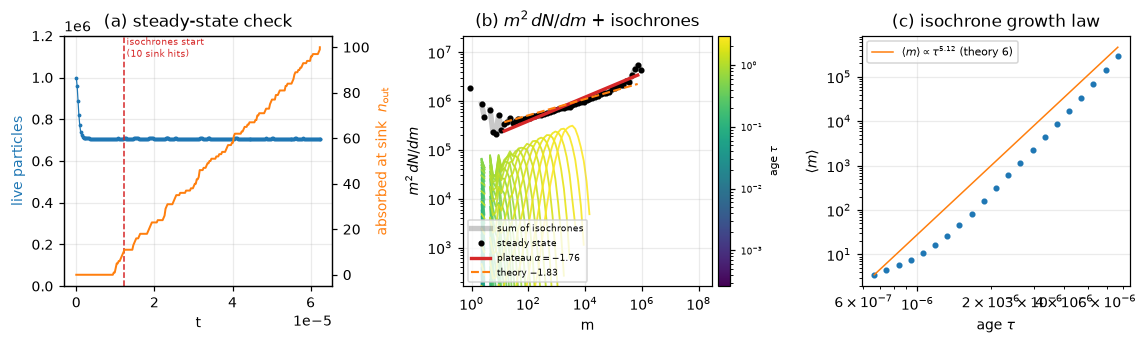

In [18]:
N_ISO_SHOW = 1000      # <<-- how many isochrones to draw on panel (b).  The line below prints
                    #      how many are available first, so you always know what you are seeing.
                    #      NOTE: AGE_STEP is now 0.05 dex (b = 6), so there are ~119 age bins
                    #      instead of 39 and "100" really does draw ~70 curves.  Drop to ~12
                    #      if panel (b) turns into a hairball.

idx3, tau3c, navail3 = pick_isochrones(r3, N_ISO_SHOW)
print("isochrones: %d of %d age bins carry statistics -> drawing %d"
      % (navail3, len(tau3c), len(idx3)))

fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))

# ---- (a) steady-state check, with the sink counter on the right axis ----------
ax[0].plot(r3["t"], r3["live"], ".-", ms=3, lw=.8, color="C0")
ax[0].set_xlabel("t"); ax[0].set_ylabel("live particles", color="C0")
ax[0].set_ylim(0, 1.2*np.max(r3["live"]))      # start at zero: no offset trick on this axis
ax[0].set_title("(a) steady-state check")
axr = ax[0].twinx(); axr.grid(False)
axr.plot(r3["t"], r3["n_out"], "-", lw=1.3, color="C1")
axr.set_ylabel(r"absorbed at sink  $n_{\rm out}$", color="C1")
if np.isfinite(r3["iso_t_begin"]):
    ax[0].axvline(r3["iso_t_begin"], ls="--", lw=1, color="C3")
    ax[0].text(r3["iso_t_begin"], ax[0].get_ylim()[1], " isochrones start\n (%d sink hits)" % N_OUT,
               fontsize=6, va="top", color="C3")

# ---- (b) COMPENSATED spectrum: m^2 dN/dm = mass per logarithmic mass interval --
c = r3["centers"]
a = ax[1]
draw_isochrones(a, r3, idx3, tau3c, tau_scale=N_SS)
if len(idx3):
    # completeness check: the isochrones must add up to the steady state
    iso_sum = r3["iso_dndm"].sum(axis=0) / max(r3["iso_snapshots"], 1)
    a.loglog(c, np.where(iso_sum > 0, iso_sum*c**2, np.nan), "-", lw=3.5, alpha=.35,
             color="0.4", zorder=2, label="sum of isochrones")
a.loglog(c, np.where(F3 > 0, F3*c**2, np.nan), "o", ms=3, color="k", zorder=4,
         label="steady state")

xs  = np.logspace(np.log10(ir3["m_lo"]), np.log10(ir3["m_hi"]), 30)
A_m = anchor_amplitude(c, F3, ir3["m_lo"], ir3["m_hi"], ir3["alpha"])
A_t = anchor_amplitude(c, F3, ir3["m_lo"], ir3["m_hi"], pr3["alpha"])
a.loglog(xs, A_m * xs**ir3["alpha"] * xs**2, "-",  lw=2.2, color="C3", zorder=5,
         label=r"plateau $\alpha=%.2f$" % ir3["alpha"])
a.loglog(xs, A_t * xs**pr3["alpha"] * xs**2, "--", lw=1.4, color="C1", zorder=5,
         label=r"theory $%.2f$" % pr3["alpha"])
compensated_ylim(a, c, F3)
a.set_xlim(.5, 3e8); a.set_xlabel("m"); a.set_ylabel(r"$m^2\,dN/dm$")
a.legend(fontsize=6, loc="lower left"); a.set_title(r"(b) $m^2\,dN/dm$ + isochrones")

# ---- (c) isochrone growth law -------------------------------------------------
if k3.sum() > 3:
    ax[2].loglog(tau3[k3], mbar3[k3], "o", ms=3)
    ax[2].loglog(tau3[k3], mbar3[k3][0]*(tau3[k3]/tau3[k3][0])**b3, "-", lw=1,
                 label=r"$\langle m\rangle\propto\tau^{%.2f}$ (theory %.0f)" % (b3, pr3["b"]))
    ax[2].legend(fontsize=7)
else:
    ax[2].set_xscale("log"); ax[2].set_yscale("log")
    ax[2].text(.5, .5, "no usable isochrones\n%d iso snapshots, %d sink hits"
               % (r3["iso_snapshots"], r3["sink_events"]),
               ha="center", va="center", fontsize=7, color="C3", transform=ax[2].transAxes)
ax[2].set_xlabel(r"age $\tau$"); ax[2].set_ylabel(r"$\langle m\rangle$")
ax[2].set_title("(c) isochrone growth law")
fig.tight_layout()


---
## Open system with fragmentation

Large bodies are injected at $m_{\rm inj}$ and fragments falling below
$m_{\rm sink}$ are absorbed — the mirror of the coagulation case, predicting the same
$\alpha$. This one is run twice, because the rule deciding which particle breaks is a
choice of physics rather than a detail of implementation.

If the heavier of the pair always breaks, whatever hit it, then the disruption rate
of a body of mass $m_0$ against a background $F(m)\propto m^{\alpha}$ is

$$\nu(m_0)\sim\int_{m_{\rm sink}}^{m_0}F(m')\,K(m_0,m')\,dm'
        \sim\int_{m_{\rm sink}/m_0} x^{\alpha}\,dx ,$$

which diverges at the lower limit whenever $\alpha<-1$. The drift is then set by the
smallest particles in the box — by the sink scale rather than by $m_0$ — the
mean-field closure is void, and the measured index locks onto $-2$ for any kernel at
all. That is a boundary effect wearing the costume of universality.

The cure is the one Dohnanyi built in: a catastrophic-disruption threshold, on the
grounds that a grain of dust does not shatter a boulder. Requiring
$m_{\rm small}\ge f\,m_{\rm large}$ with $f$ of order a tenth to one restricts the
integral to $x\in[f,1]$, which is scale free, and recovers the predicted index. A
closed system is immune by construction, because its packet is narrow and every
partner is already of order $m_0$ — which is why the closed runs agree with the
theory at $f=0$ and the open ones do not.

The cell below runs $f=0$ and $f=0.3$, and the two spectrum panels are meant to be
read against each other.


In [12]:
# RANGE IS CAPPED BY MEMORY, not by taste.  Without resampling a completed cascade holds
# N0 * m_inj/m_sink particles, one array slot each.  m_inj = 1e7 asks for 1e10 of them --
# and it never even got that far: 1e7 sits ABOVE the old top edge 10^6.9, mass_to_bin
# clamped it into the last bin, and the very first pair tripped
#     RuntimeError: Majorant violated: K(1e+07,1e+07) > fmaj[108,108]
# 4 decades with N0 = 400 needs 4e6 particles (~130 MB) and the cascade can actually
# COMPLETE inside the event budget, which the old 1e4/1000/9e5 combination could not.
M_INJ4, M_SINK4 = 1.0e6, 1.0
N04   = 400
ME4   = 5.0e6                                  # ~ N0*m_inj/m_sink, i.e. a completed cascade
check_grid(M_INJ4, M_SINK4)

# Same story as q3: the target population is what a full cascade holds, and the kernel
# is evaluated where the NUMBER lives, i.e. at the sink scale.
N_FULL4 = N04 * M_INJ4 / M_SINK4
q4      = 0.5 * KERNEL(M_SINK4, M_SINK4) * N_FULL4**2 / (M_INJ4/M_SINK4)
t_c4    = 1.0 / (KERNEL(M_INJ4, M_INJ4) * N04)   # collision time at the START of the run
print("N_full = %.3g   q4 = %.3e   t_c4 = %.3e" % (N_FULL4, q4, t_c4))

runs4 = {}
for f_ratio in (0.0, 0.3):
    runs4[f_ratio] = BF.simulate(
        process="fragmentation", system="open", kernel=KERNEL, edges=EDGES,
        ic={"m":M_INJ4, "N":N04}, frag_min_ratio=f_ratio,
        injection_rate=q4/max(f_ratio,0.15)*0.15,
        injection_mass=M_INJ4, sink_mass=M_SINK4,
        snapshot_mode="events", snapshot_stride=int(ME4//150), max_events=ME4,  # 150 snapshots:
        # isochrone histogram is accumulated ONCE PER SNAPSHOT, so a coarse cadence
        # starves it.  Snapshots are cheap here; ages are not.
        # v2: isochrones for FRAGMENTATION too, gated on the same physical criterion.
        iso_age_edges=10.0**np.arange(-3, 3, AGE_STEP) * t_c4,
        iso_start_sink=10,
        rng=np.random.default_rng(4), verbose=False)

pr4 = BF.predict("open", LAM)
print("theory alpha = %+.3f,  b = %.3f\n" % (pr4["alpha"], pr4["b"]))

fits4, irs4, iso4 = {}, {}, {}
for f_ratio, r in runs4.items():
    last, _nss = steady_spectrum(r)
    irs4[f_ratio]  = BF.find_inertial_range(r["centers"], last)     # <== the measurement
    fits4[f_ratio] = BF.fit_powerlaw(r["centers"], last,
                                     *BF.guard_band(M_SINK4, M_INJ4, 0.4))   # cross-check

    # Decay law.  Open fragmentation shrinks a body with age, so <m> is read in
    # (tau* - tau) exactly as closed fragmentation is in case 2: m ~ (tau*-tau)^b
    # means m^(1/b) is LINEAR in tau, so tau* comes from where that line crosses zero.
    tau, mbar, nn = BF.iso_mean_mass(r["iso_counts"], r["centers"], r["iso_age_edges"])
    kk = np.isfinite(mbar) & (nn > 1e3) & (mbar > 3*M_SINK4) & (mbar < 0.3*M_INJ4)
    if kk.sum() > 3:
        pl     = np.polyfit(tau[kk], mbar[kk]**(1.0/pr4["b"]), 1)
        t_star = -pl[1]/pl[0]
        g      = BF.growth_fit(tau, mbar, t_star=t_star*1.0000001, mask=kk)
        b4     = g["b"]
    else:
        t_star, b4 = np.nan, np.nan
    iso4[f_ratio] = dict(tau=tau, mbar=mbar, n=nn, k=kk, t_star=t_star, b=b4)

    # Why the isochrones can still be thin here.  Injection at m_inj delivers only a
    # handful of bodies over the time this run reaches, so essentially every live
    # particle still descends from the INITIAL CONDITION and inherits t_born = 0.
    # Age then equals wall-clock time for everyone at once and the age axis is
    # degenerate -- the isochrones degrade into "spectrum vs time".  The same fact
    # shows up as M_out/M_in > 1: the sink is draining the initial reservoir, whose
    # mass never entered M_in.  A real age spectrum needs the injected flux to
    # dominate, i.e. a much longer run (or BF.py, with weights).
    frac_ic = float(np.mean(r["final_inj_time"] == 0.0))

    tag = "NON-LOCAL (no threshold)" if f_ratio == 0 else ("local, f = %.2g" % f_ratio)
    ir  = irs4[f_ratio]
    print("  %-26s live %d->%d  sink=%d  M_out/M_in=%.2f" %
          (tag, r["live"][0], r["live"][-1], r["sink_events"],
           r["M_out"][-1]/max(r["M_in"][-1], 1)))
    print("      plateau  [%9.3g,%9.3g] alpha = %+.3f +- %.3f over %.2f dec   <== the answer"
          % (ir["m_lo"], ir["m_hi"], ir["alpha"], ir["scatter"], ir["decades"]))
    print("      guard band                     alpha = %+.3f   R2 = %.3f   (cross-check)"
          % (fits4[f_ratio]["alpha"], fits4[f_ratio]["r2"]))
    print("      isochrones: %d snapshots, %d usable age bins, b = %.3f (theory %.0f)"
          % (r["iso_snapshots"], kk.sum(), b4, pr4["b"]))
    print("      %.1f%% of live particles still descend from the IC (t_born = 0):"
          " while this is near 100%%, the age axis is degenerate and b is not a measurement"
          % (100*frac_ic))

    add_last_run(r, "open_fragmentation_conservative_%s_f%.2f"
                 % (KERNEL.__name__.replace("kernel_", ""), f_ratio),
                 analysis=dict(
                     alpha_plateau=ir["alpha"], alpha_scatter=ir["scatter"],
                     plateau_decades=ir["decades"],
                     plateau_m_lo=ir["m_lo"], plateau_m_hi=ir["m_hi"],
                     alpha_guard=fits4[f_ratio]["alpha"], guard_r2=fits4[f_ratio]["r2"],
                     alpha_theory=pr4["alpha"], b_theory=pr4["b"], b_iso=b4,
                     t_star=t_star, iso_age_bins_used=kk.sum(), frac_from_ic=frac_ic,
                     f_ratio=f_ratio, lam=LAM, N0=N04, m_inj=M_INJ4, m_sink=M_SINK4,
                     q=runs4[f_ratio]["meta"]["injection_rate"], t_c=t_c4))


for f_ratio in runs4:
    ir = irs4[f_ratio]
    RESULTS["4 open frag f=%.2g" % f_ratio] = dict(
        b=iso4[f_ratio]["b"], b_th=pr4["b"], alpha=ir["alpha"], alpha_th=pr4["alpha"],
        scatter=ir["scatter"], decades=ir["decades"], alpha_gb=fits4[f_ratio]["alpha"])


N_full = 4e+08   q4 = 3.200e+11   t_c4 = 6.250e-08
theory alpha = -1.833,  b = 6.000

  NON-LOCAL (no threshold)   live 400->5008597  sink=2099  M_out/M_in=0.00
      plateau  [     1.12, 1.41e+03] alpha = -0.057 +- 0.125 over 3.10 dec   <== the answer
      guard band                     alpha = -1.048   R2 = 0.703   (cross-check)
      isochrones: 142 snapshots, 55 usable age bins, b = 4.695 (theory 6)
      4.0% of live particles still descend from the IC (t_born = 0): while this is near 100%, the age axis is degenerate and b is not a measurement
saved -> runs\open_fragmentation_conservative_geometric_f0.00.npz   (0.11 MB, stop = max_events)
  local, f = 0.3             live 400->5003395  sink=7858  M_out/M_in=0.00
      plateau  [     1.12,      355] alpha = -0.070 +- 0.139 over 2.50 dec   <== the answer
      guard band                     alpha = -1.085   R2 = 0.853   (cross-check)
      isochrones: 145 snapshots, 21 usable age bins, b = 4.777 (theory 6)
      6.7% of live partic

f = 0 : 42 of 119 age bins carry statistics -> drawing 10
f = 0.3 : 21 of 119 age bins carry statistics -> drawing 10


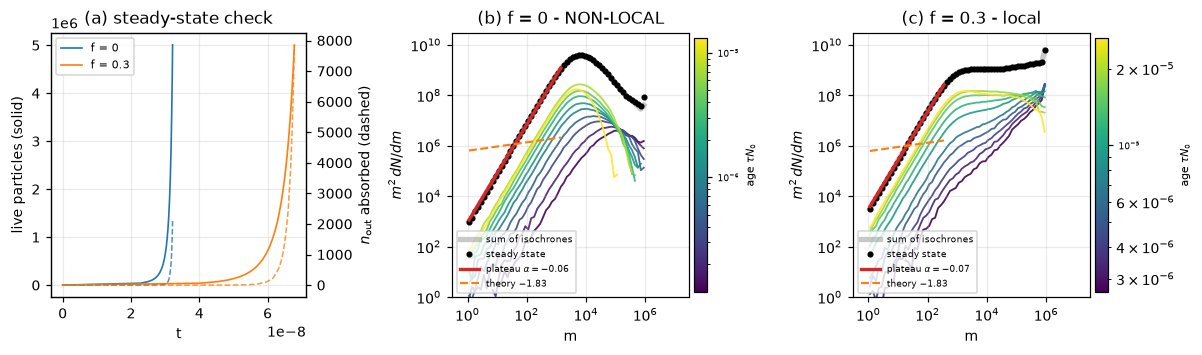

In [13]:
N_ISO_SHOW4 = 10     # <<-- isochrones per panel; availability is printed below

fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))

# ---- (a) population and sink flux, both runs ---------------------------------
axr = ax[0].twinx(); axr.grid(False)
for i, (f_ratio, r) in enumerate(runs4.items()):
    ax[0].plot(r["t"], r["live"], "-", lw=1.1, color="C%d" % i, label="f = %.2g" % f_ratio)
    axr.plot(r["t"], r["n_out"], "--", lw=1.0, color="C%d" % i, alpha=.8)
ax[0].set_xlabel("t"); ax[0].set_ylabel("live particles (solid)")
axr.set_ylabel(r"$n_{\rm out}$ absorbed (dashed)")
ax[0].legend(fontsize=7); ax[0].set_title("(a) steady-state check")

# ---- (b),(c) compensated spectra with isochrones -----------------------------
for i, (f_ratio, r) in enumerate(runs4.items()):
    a    = ax[1+i]
    c    = r["centers"]
    last, _nss = steady_spectrum(r)
    ir   = irs4[f_ratio]

    idx, tauc, navail = pick_isochrones(r, N_ISO_SHOW4)
    print("f = %.2g : %d of %d age bins carry statistics -> drawing %d"
          % (f_ratio, navail, len(tauc), len(idx)))
    draw_isochrones(a, r, idx, tauc, tau_scale=N04, cbar_label=r"age $\tau N_0$")

    iso_sum = r["iso_dndm"].sum(axis=0) / max(r["iso_snapshots"], 1)
    a.loglog(c, np.where(iso_sum > 0, iso_sum*c**2, np.nan), "-", lw=3.5, alpha=.35,
             color="0.4", zorder=2, label="sum of isochrones")
    a.loglog(c, np.where(last > 0, last*c**2, np.nan), "o", ms=3, color="k", zorder=4,
             label="steady state")
    if np.isfinite(ir["m_lo"]):
        xs  = np.logspace(np.log10(ir["m_lo"]), np.log10(ir["m_hi"]), 30)
        A_m = anchor_amplitude(c, last, ir["m_lo"], ir["m_hi"], ir["alpha"])
        A_t = anchor_amplitude(c, last, ir["m_lo"], ir["m_hi"], pr4["alpha"])
        a.loglog(xs, A_m * xs**ir["alpha"] * xs**2, "-", lw=2.2, color="C3", zorder=5,
                 label=r"plateau $\alpha=%.2f$" % ir["alpha"])
        a.loglog(xs, A_t * xs**pr4["alpha"] * xs**2, "--", lw=1.4, color="C1", zorder=5,
                 label=r"theory $%.2f$" % pr4["alpha"])
    compensated_ylim(a, c, last)

    a.set_ylim(1e0, 3e10); a.set_xlim(.3, 3e7); a.set_xlabel("m"); a.set_ylabel(r"$m^2\,dN/dm$")
    a.legend(fontsize=6, loc="lower left")
    a.set_title("(b) f = 0 - NON-LOCAL" if f_ratio == 0 else "(c) f = %.2g - local" % f_ratio)
fig.tight_layout()


---
## Summary

One row per run. `plateau` is the mean local slope over the longest flat stretch of
$\Gamma(m)$, with its scatter and its width in decades; `guard` is the a-priori band
fit kept as an independent cross-check, and the two are expected to agree. `b` comes
from the isochrones, read as $\langle m\rangle\propto\tau^{\,b}$ for coagulation and
as $\langle m\rangle\propto(\tau_*-\tau)^{\,b}$ for fragmentation.

Read `dec` before believing `plateau`. The expected failure is the fragmentation run
at $f=0$, where the non-local disruption rule drives the drift from the sink scale
and pushes the index towards $-2$ whatever the kernel; its narrow plateau is the
notebook announcing that the number next to it is a diagnosis rather than a
measurement.

Every run above has been written into `runs/`. The analysis notebooks there reload
those files and rebuild each figure separately, so nothing below needs to be re-run
to change a plot.


In [14]:
hdr = ("%-22s | %7s %7s | %8s %7s %6s | %8s %8s" %
       ("case", "b", "b_th", "plateau", "+-", "dec", "guard", "theory"))
print(hdr); print("-" * len(hdr))
for name, d in RESULTS.items():
    print("%-22s | %7.3f %7.3f | %+8.3f %7.3f %6.2f | %+8.3f %+8.3f" %
          (name, d["b"], d["b_th"], d["alpha"], d["scatter"], d["decades"],
           d["alpha_gb"], d["alpha_th"]))
print("\nplateau = find_inertial_range (longest flat run in the local slope) -- THE answer.")
print("guard   = the a-priori band fit, kept as an independent cross-check.")
print("dec     = plateau width in decades; below ~1 the index is not a measurement.")
print("b = nan  = the age axis was degenerate, see the note in the case-4 cell.")


case                   |       b    b_th |  plateau      +-    dec |    guard   theory
--------------------------------------------------------------------------------------
3 open coag            |   5.123   6.000 |   -1.756   0.141   4.70 |   -1.822   -1.833
4 open frag f=0        |   4.695   6.000 |   -0.057   0.125   3.10 |   -1.048   -1.833
4 open frag f=0.3      |   4.777   6.000 |   -0.070   0.139   2.50 |   -1.085   -1.833

plateau = find_inertial_range (longest flat run in the local slope) -- THE answer.
guard   = the a-priori band fit, kept as an independent cross-check.
dec     = plateau width in decades; below ~1 the index is not a measurement.
b = nan  = the age axis was degenerate, see the note in the case-4 cell.
